In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('diamonds.csv',encoding='utf-8')

#SHAPE OF DF

df.shape


(53940, 10)

In [2]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
# INFO OF DF

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


1)THERE ARE 53940 ROWS AND 10 COLUMNS
2)NO NULL VALUES PRESENT IN DATASET

In [4]:
# COLUMNS OF DF
df.columns.tolist()

['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']

In [5]:
#FINDING NULL VALUES OF DF
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [6]:
#FINDING DUPLICATES OF DF
df.duplicated().sum()

np.int64(146)

In [7]:
#SUMMARY OF DF
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [8]:
#SUMMARY OF OBJECTS OF DF
df.describe(exclude =np.number)

,cut,color,clarity
count,53940,53940,53940
unique,5,7,8
top,Ideal,G,SI1
freq,21551,11292,13065


In [9]:
#converting 0 or null values to nan
df[['x','y','z']] = df[['x','y','z']].replace(0, np.nan)
df = df.dropna(subset=['x','y','z'])

In [10]:
df = df.drop_duplicates()

In [11]:
df.shape

(53775, 10)

In [12]:
df.duplicated().sum()

np.int64(0)

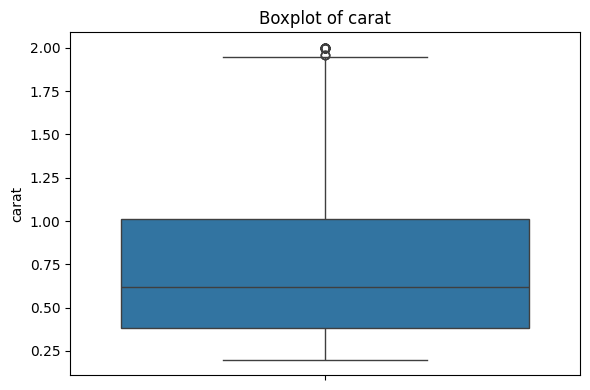

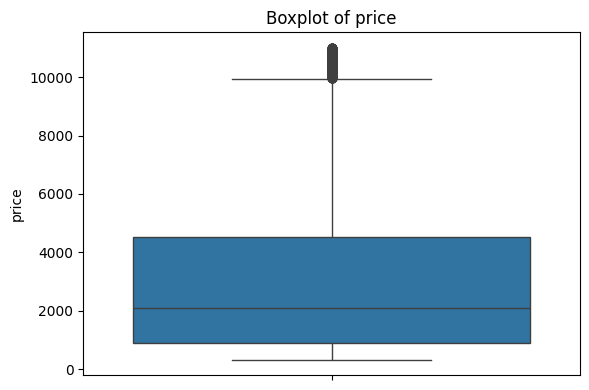

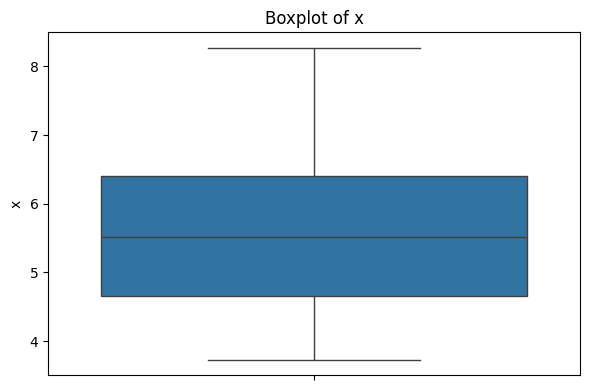

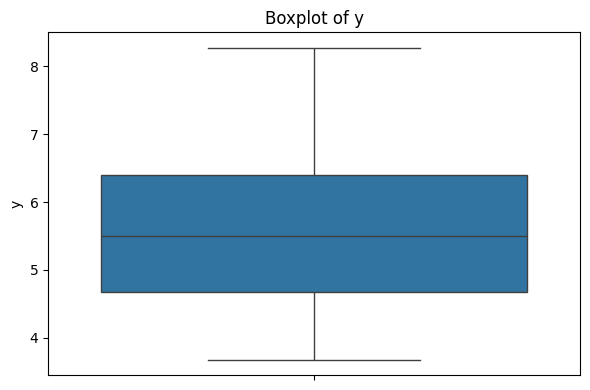

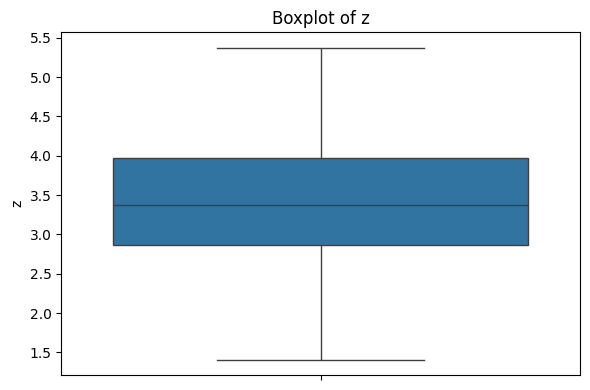

In [13]:

def remove_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]
    return df


df = remove_outliers_iqr(df, ['carat', 'price', 'x', 'y', 'z'])


import seaborn as sns
import matplotlib.pyplot as plt

for col in ['carat', 'price', 'x', 'y', 'z']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, y=col)
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

In [14]:
df[['carat', 'price', 'x', 'y', 'z']].skew().sort_values(ascending=False)


price    1.125809
carat    0.657875
z        0.218858
x        0.217930
y        0.212450
dtype: float64

In [15]:

# Applying log and sqrt transformations
df['price_log'] = np.log1p(df['price'])



In [16]:
df.to_csv('diamonds_cleaned.csv', encoding='utf-8', index=False)


